In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import marimo as mo

# Mandat no. 3 : Simulations Monte-Carlo

## Fonctions des temps d'arrivés

### Processus de poisson et exponentielle.

La fonction de masse de la loi de Poisson est donnée par :
$$
P(X=x)=\frac{e^{-\lambda T}(\lambda T)^x}{x!}
$$
- Où $\lambda$ est le taux d'arrivée.
- T est une durée de temps.


Cette fonction donne la probabilité que $x$ arrivées surviennent dans un intervalle de temps $T$. Cependant, ici on s'intéresse plutôt au *temps entre chaque arrivée*.
Si $x$ représente le nombre d'arrivées dans l'intervalle $[0,T]$, posé $x=0$ devrait donnée la probabilité qu'aucune arrivée ne survienne dans cet intervalle.

Autrement dit, l'absence d'événement dans $[0,T]$ c'est la probabilité que le temps jusqu'à la prochaine arrivée soit plus grand que $T$:
$$
P(T_A > T)
$$

$x$ est donc remplacé par $0$ dans la formule de Poisson, et c'est simplifié:
$$
P(X=0)=\frac{e^{-\lambda T}(\lambda T)^0}{0!}
$$
$$
P(X=0)=\frac{e^{-\lambda T}\cdot 1}{1}
$$
$$
P(X=0)=e^{-\lambda T}
$$

Ça donne une fonction exponentielle décroissante. Plus $T$ augmente, plus la probabilité diminue.
C'est la fonction de survie:
$$
P(T_A > T) = e^{-\lambda T}
$$

La CDF s'obtient en prenant le complément, étant donnée la présence d'un $>$ dans la formule de survie.
$$
F(T)=P(T_A \le T)=1 - e^{-\lambda T}
$$

### Inversion de la fonction

Chaque joueur arrive à un temps $P$, puis quitte après une session de jeu de durée aléatoire $Q$. Donc, chaque joueur est actif dans un intervalle $[P, P+Q]$.

L'activité d'un joueur est donc:
$$
P \le t \le P + Q
$$

Ça permet de déterminer combien de joueurs sont actifs à n'importe quel instant (minute) $t$.
La génération des temps d'arrivée est fait avec la méthode de transformation inverse.
Il faut donc appliqué une transformation inverse sur la CDF trouvé plus haut. On résoud pour $T$.
$$
F(T)=1 - e^{-\lambda T}
$$
$$
U = 1 - e^{-\lambda T}
$$
$$
U - a = e^{-\lambda T}
$$
$$
\ln(1 - U) = -\lambda T
$$
$$
T = \frac{\ln(1 - U)}{-\lambda}
$$
Ici, $U$ est une variable aléatoire continue uniforme entre $[0,1]$.

### Python
La fonction python suivante génère les temps d'arrivés $P$ en utilisant la transformation inverse trouvé plus haut.
Elle prend comme paramètres le taux d'arrivés par minutes et le nombre de données à générés.

In [ ]:
def generate_arrival_times(arrivals_per_minutes, sample_size):
    uniform_randoms = np.random.rand(sample_size)
    return -np.log(uniform_randoms) / arrivals_per_minutes

## Temps de jeux des joueurs
La variable aléatoire normale $Q$ a été déterminée dans le mandat 2, avec sa moyenne et sa variance.
Elle dicte le nombre d'heures qu'un joueur passe sur le jeux.

La variable est indépendante du temps d'arrivé ou tout autres valeurs associés au mandat-03.

Pour la générer l'implémentation manuel de l'algorithme de Box-Muller est fesable, mais c'est inutile,
puisque NumPy a déjà une implémentation dans la fonction `randn`, qui à été confirmé comme équivalente
lors des laboratoires.

In [ ]:
def generate_play_durations(average, variance, sample_size):
    return np.random.normal(average, variance, sample_size)

## Paramètres de simulation

In [ ]:
tested_arrivals_per_minutes = [10, 67, 100] # Taux d'arrivés testés (branchements / minutes)
MU_Q = 280.56                               # Moyenne de temps de jeux d'un joueur (minutes)
SIGMA_Q = 50.38                             # Variance du temps de jeux (minutes)
sample_size = 10000                         # N (minutes)

## Fonction de simulation
Avec le taux de branchements, la transformation inverse calculé plus haut est utilisé pour
donnée un nombre de nouveau joueurs à chaque minutes de la simulation.
Leurs temps d'arrivé est calculé progressivement au fur et à mesure que le temps avance.
Par la suite, un nombre de temps de jeux est généré pour chaque branchements.
Le temps de départ du joueur est ensuite calculé.

Le nombre de joueurs actif à n'importe quel instant $t$ est finalement calculé en appliquant
$$
    T_{\text{arrivé}} \le t \le T_{\text{départ}}
$$

In [ ]:
def simulate(arrivals_per_minutes, simulation_time):
    arrival_times = []
    t = 0

    # Generating a P for each minute of the simulation
    # While making the arrivals later and later.
    while t < simulation_time:
        t += generate_arrival_times(arrivals_per_minutes, 1)[0]
        arrival_times.append(t)
    arrival_times = np.array(arrival_times)


    play_time = generate_play_durations(
        MU_Q,
        SIGMA_Q,
        len(arrival_times))
    departures = arrival_times + play_time

    # This removes the warmup time of the population of servers.
    # Without this, the averages are off because they assume infinite
    # amount of time.
    t_start = 0.3 * simulation_time  # remove transient phase
    t_values = np.linspace(t_start, simulation_time, 500)

    active_players = []
    for t in t_values:
        active = np.sum((arrival_times <= t) & (departures >= t))
        active_players.append(active)

    return arrival_times, play_time, t_values, active_players

## Roulement de la simulation
Le code suivant éxecute la simulation monte-carlo pour chaque taux de branchements voulu.
Elle vient sauvegarder certaines valeurs analysé afin d'être utilisé dans les histogrammes
et des affichages.

Elle prouve aussi la réponse au besoin d'être capable de dire combiens de joueurs sont connecté
à un instant $t$, et fait une comparaison de la moyenne théorique ($\lambda\times\mu_Q$) versus réel.

In [ ]:
results = []

# Testing every rates set in the test array up in this document
for rate in tested_arrivals_per_minutes:
    arrivals, play_time, t, active_players = simulate(rate, sample_size)
    theorical_average = rate * MU_Q
    real_average = np.mean(active_players)

    # Points à différents instants
    t_check = [10, 50, 500]
    active_at_t = {ti: np.sum((arrivals <= ti) & (arrivals + play_time >= ti)) for ti in t_check}

    # Sauvegarde des résultats
    results.append({
        "rate": rate,
        "sample_size": sample_size,
        "moyenne_theorique": theorical_average,
        "moyenne_reel": real_average,
        "diff": real_average - theorical_average,
        "peak": np.max(active_players),
        "active_at_t": active_at_t,
        "arrivals": arrivals,
        "play_time": play_time
    })

In [ ]:
report = ""
for _r in results:
    report += f"""## {_r["rate"]} branchements / minute
    - Temps de la simulation:\t{_r["sample_size"]} minutes
    - Moyennes de joueurs actifs:
        - Échantillon / réel: {_r["moyenne_reel"]:.2f}
        - Théorique:          {_r["moyenne_theorique"]:.2f}
        - Différence:         {_r["diff"]:.2f}
    - Peak de joueurs: {_r["peak"]}
    - Joueurs actifs à différents instants:
    {"".join([f"\t- t={ti} min : {n}\n" for ti, n in _r["active_at_t"].items()])}\n"""
mo.md(report)

<span class="markdown prose dark:prose-invert contents"><h2 id="10-branchements-minute">10 branchements / minute</h2>
<div class="language-text highlight"><pre><span></span><code>- Temps de la simulation:   10000 minutes

- Moyennes de joueurs actifs:

    - Échantillon / réel: 2793.12

    - Théorique:          2805.60

    - Différence:         -12.48

- Peak de joueurs: 2900

- Joueurs actifs à différents instants:

    - t=10 min : 90

    - t=50 min : 489

    - t=500 min : 2806
</code></pre></div>
<h2 id="67-branchements-minute">67 branchements / minute</h2>
<div class="language-text highlight"><pre><span></span><code>- Temps de la simulation:   10000 minutes

- Moyennes de joueurs actifs:

    - Échantillon / réel: 18847.29

    - Théorique:          18797.52

    - Différence:         49.77

- Peak de joueurs: 19264

- Joueurs actifs à différents instants:

    - t=10 min : 620

    - t=50 min : 3200

    - t=500 min : 18660
</code></pre></div>
<h2 id="100-branchements-minute">100 branchements / minute</h2>
<div class="language-text highlight"><pre><span></span><code>- Temps de la simulation:   10000 minutes

- Moyennes de joueurs actifs:

    - Échantillon / réel: 28082.55

    - Théorique:          28056.00

    - Différence:         26.55

- Peak de joueurs: 28429

- Joueurs actifs à différents instants:

    - t=10 min : 971

    - t=50 min : 4971

    - t=500 min : 27987
</code></pre></div></span>

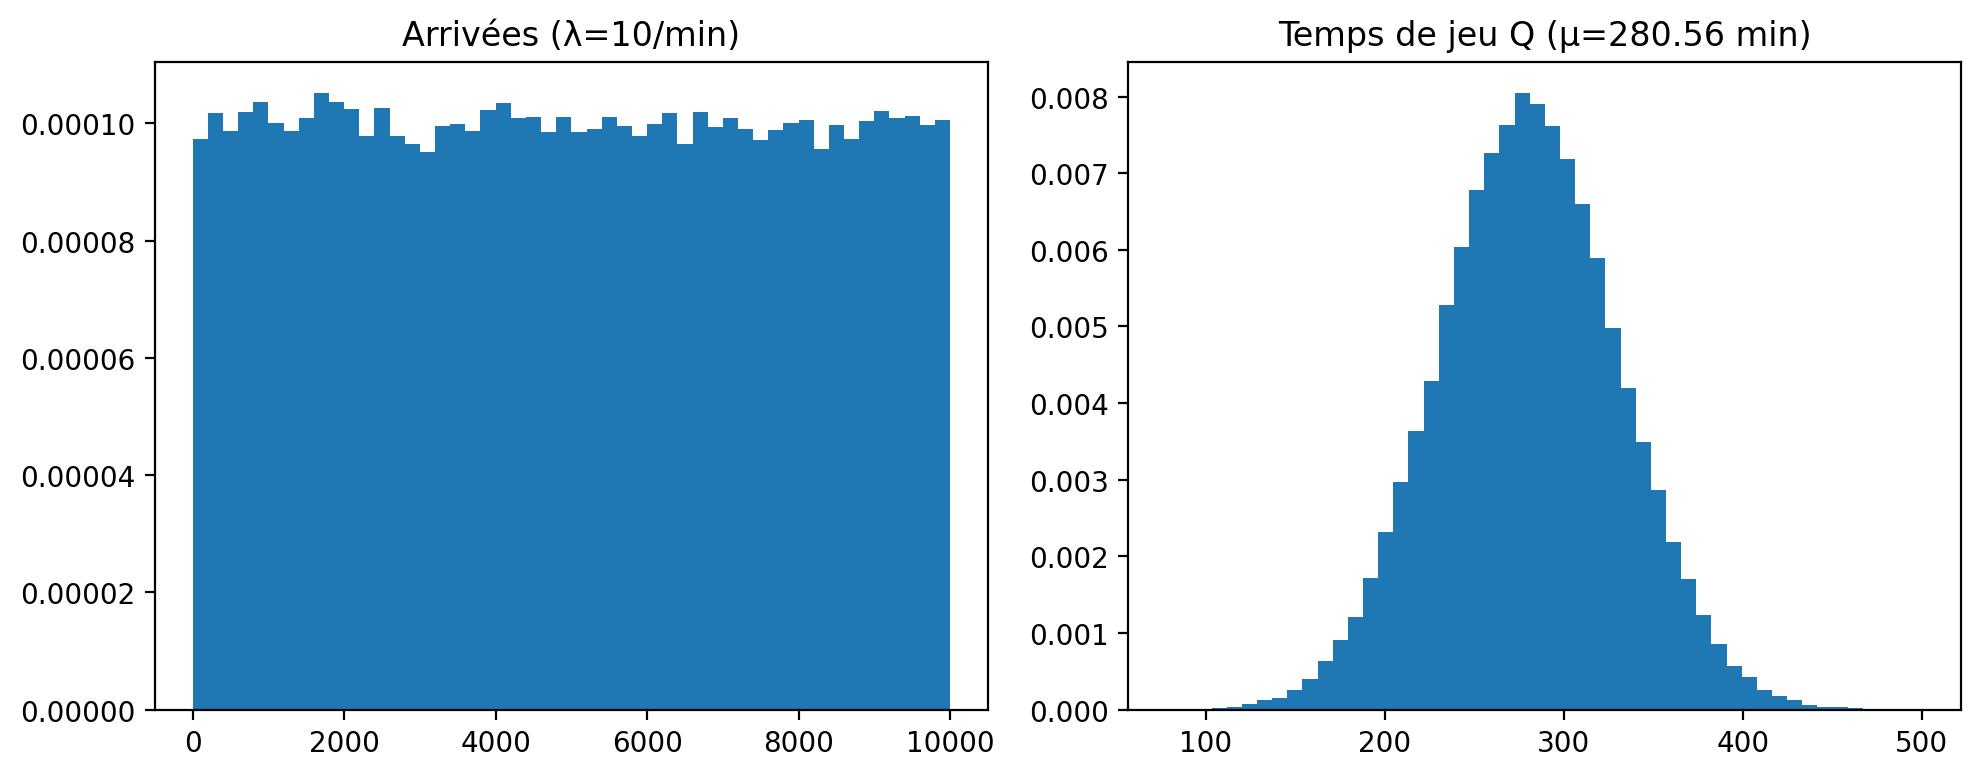

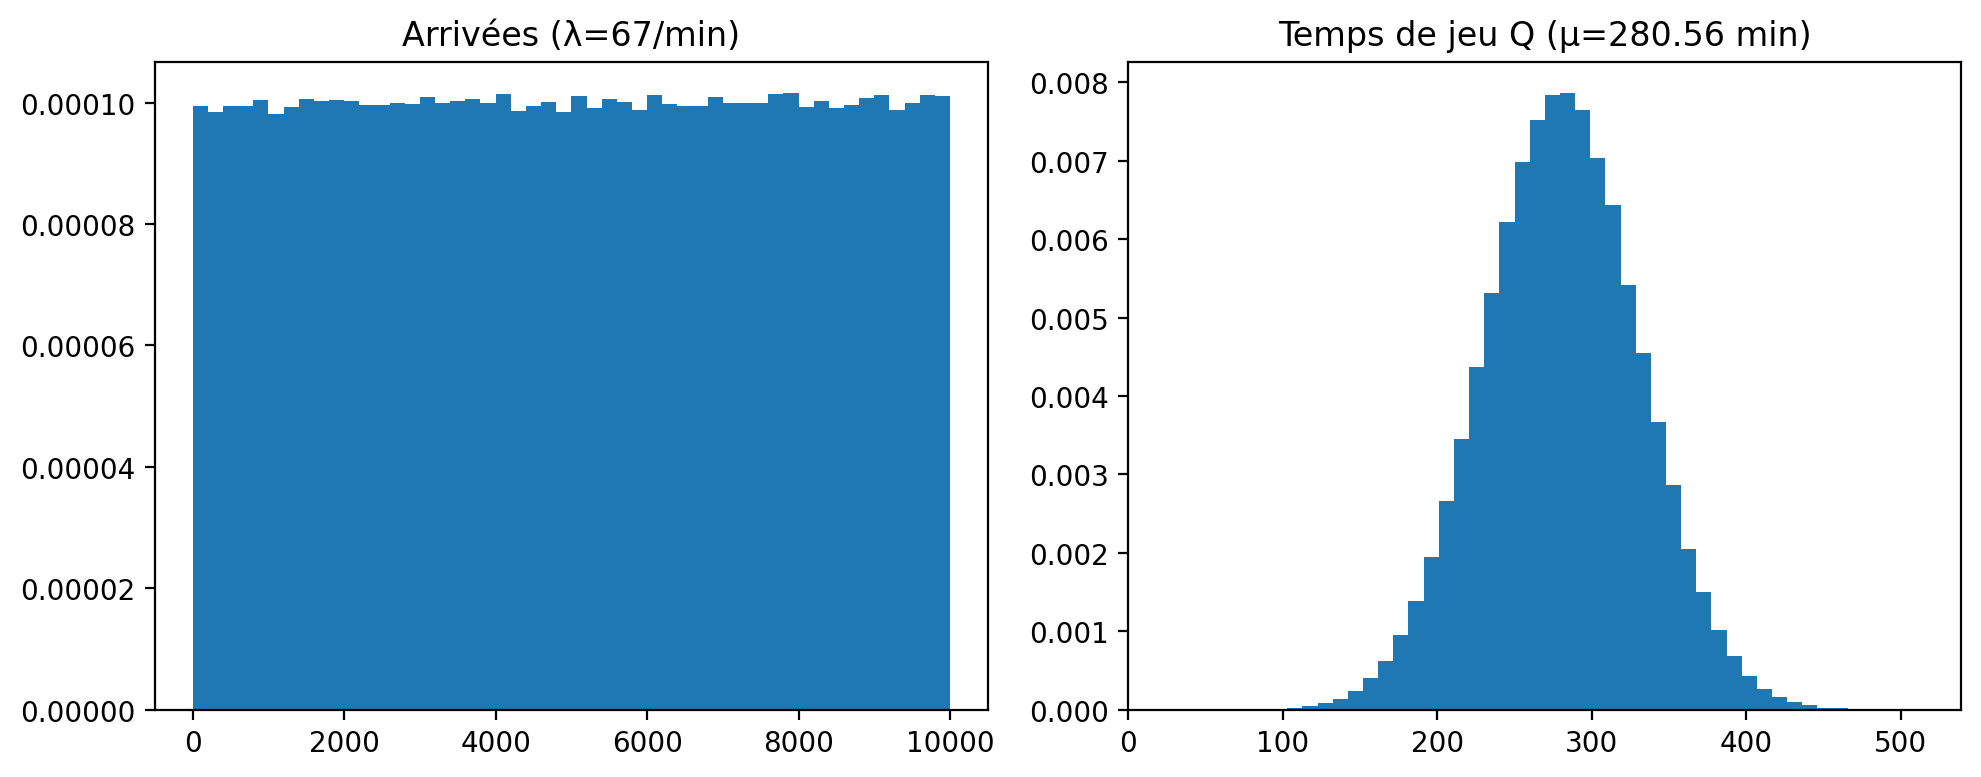

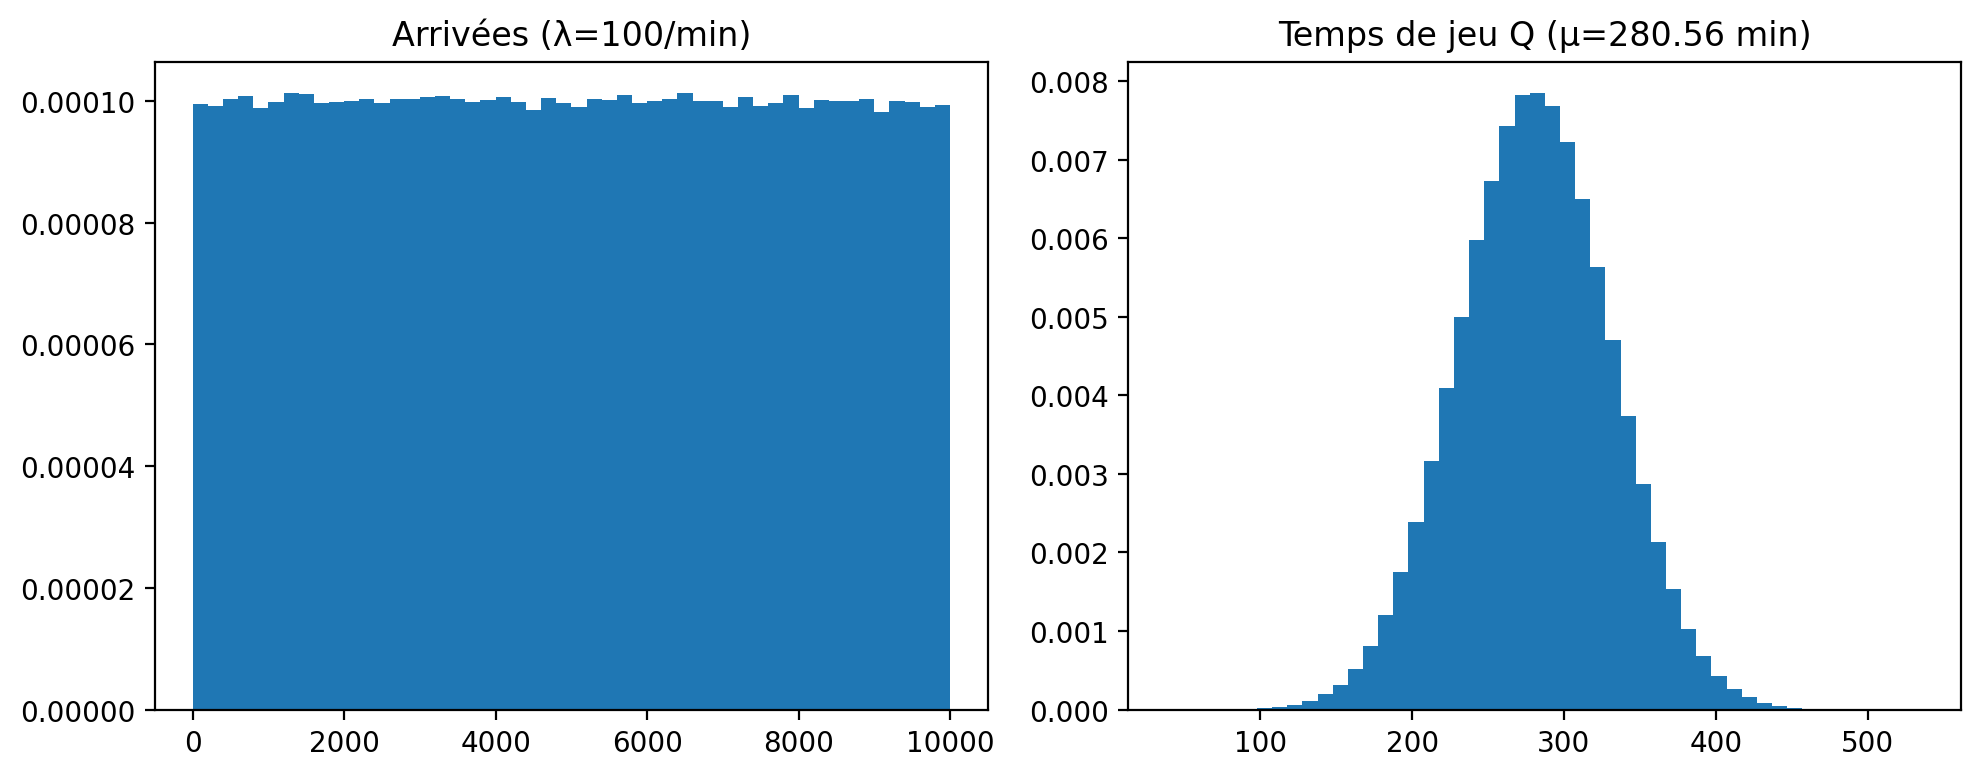

In [ ]:
for _r in results:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(_r['arrivals'], bins=50, density=True)
    plt.title(f"Arrivées (λ={_r['rate']}/min)")

    plt.subplot(1,2,2)
    plt.hist(_r['play_time'], bins=50, density=True)
    plt.title(f"Temps de jeu Q (μ={MU_Q} min)")

    plt.tight_layout()
    plt.show()

## Conclusion de la simulation
C'est une belle simulation, mais malheureusement elle est très loin d'une situation réel.
En effet, elle assume un taux de branchement constant à travers la journée, tandis que le taux change en fonction de l'heure.
Elle assume aussi une moyenne de temps de jeux constant, alors qu'en réalité, les gens jouent plus les fins de semaines que les journées de travail.

Tout ceci ne prend pas en compte le plus gros problème potentiel. Lorsqu'un jeux est mis sur le marché, on observe une fonction décroissante du
nombre de joueur à travers le temps, avec un énorme montant de joueurs au tout début de la mise en marché.
S'ils utilisent des moyennes pour quantifié leurs besoins en serveurs, la réalité vas vite les rattrapés lors du lancement du jeux.

Ils ont besoin au minimum du double de l'infrastructure prévus pour les premières semaines de la mises en marché, avec possibilités d'aggrendissements
temporaires lors d'évènements saisoniers ou des periodes de fêtes nationaux.

En bref, c'est une bonne simulation de moyenne, mais ça ne devrait pas être la seule métrique de prise de décisions pour l'infrastructure de serveurs.